## 0. Introduction

The aim of this lab is to get familiar with **regression problems**, the concepts of **under/over-fitting**, and **regularization**.


1.   This lab is the first course-work activity **Assignment 1 Part 1: Regression**
2. Assignment 1 is split into 3 parts: Part 1 - Regression (Lab 3), and Part 2 - Classification (Lab 4) and Part 3 - Neural Networks (Lab 6). The three parts need to be submitted together by  **Monday, 11th November 2024, 10:00am**
3. All questions need to be completed and are assessed.
4. For each lab, a report answering the <font color = 'red'>**questions in red**</font> should be included along with the completed Notebook (.ipynb)
5. The report should be a separate file in **pdf format** (so **NOT** *doc, docx, notebook* etc.).
6. Make sure that **any figures or code** you comment on, are **included in the report**.
7. There are three parts of Assignment 1, therefore you should submit a zip file that contains 1 x Notebook and 1 x PDF for each part. In total: 3 x Notebooks and 3 x PDFs in the submission zip. Make sure the file is well identified with your name, student number, assignment number (for instance, Assignment 1), module code.
7. No other means of submission other than the appropriate QM+ link is acceptable at any time (so NO email attachments, etc.)
8. **PLAGIARISM** <ins>is an irreversible non-negotiable failure in the course</ins> (if in doubt of what constitutes plagiarism, ask!).


For this lab we will use the [diabetes](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html) dataset. Our task is to predict disease progression of diabetes, given some variables such as age, sex, body mass index, blood pressure and blood serum measurements. For more details, follow the link above.

In [ ]:
import torch
from torch import nn
from sklearn import model_selection
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from IPython import display

import typing
%matplotlib inline

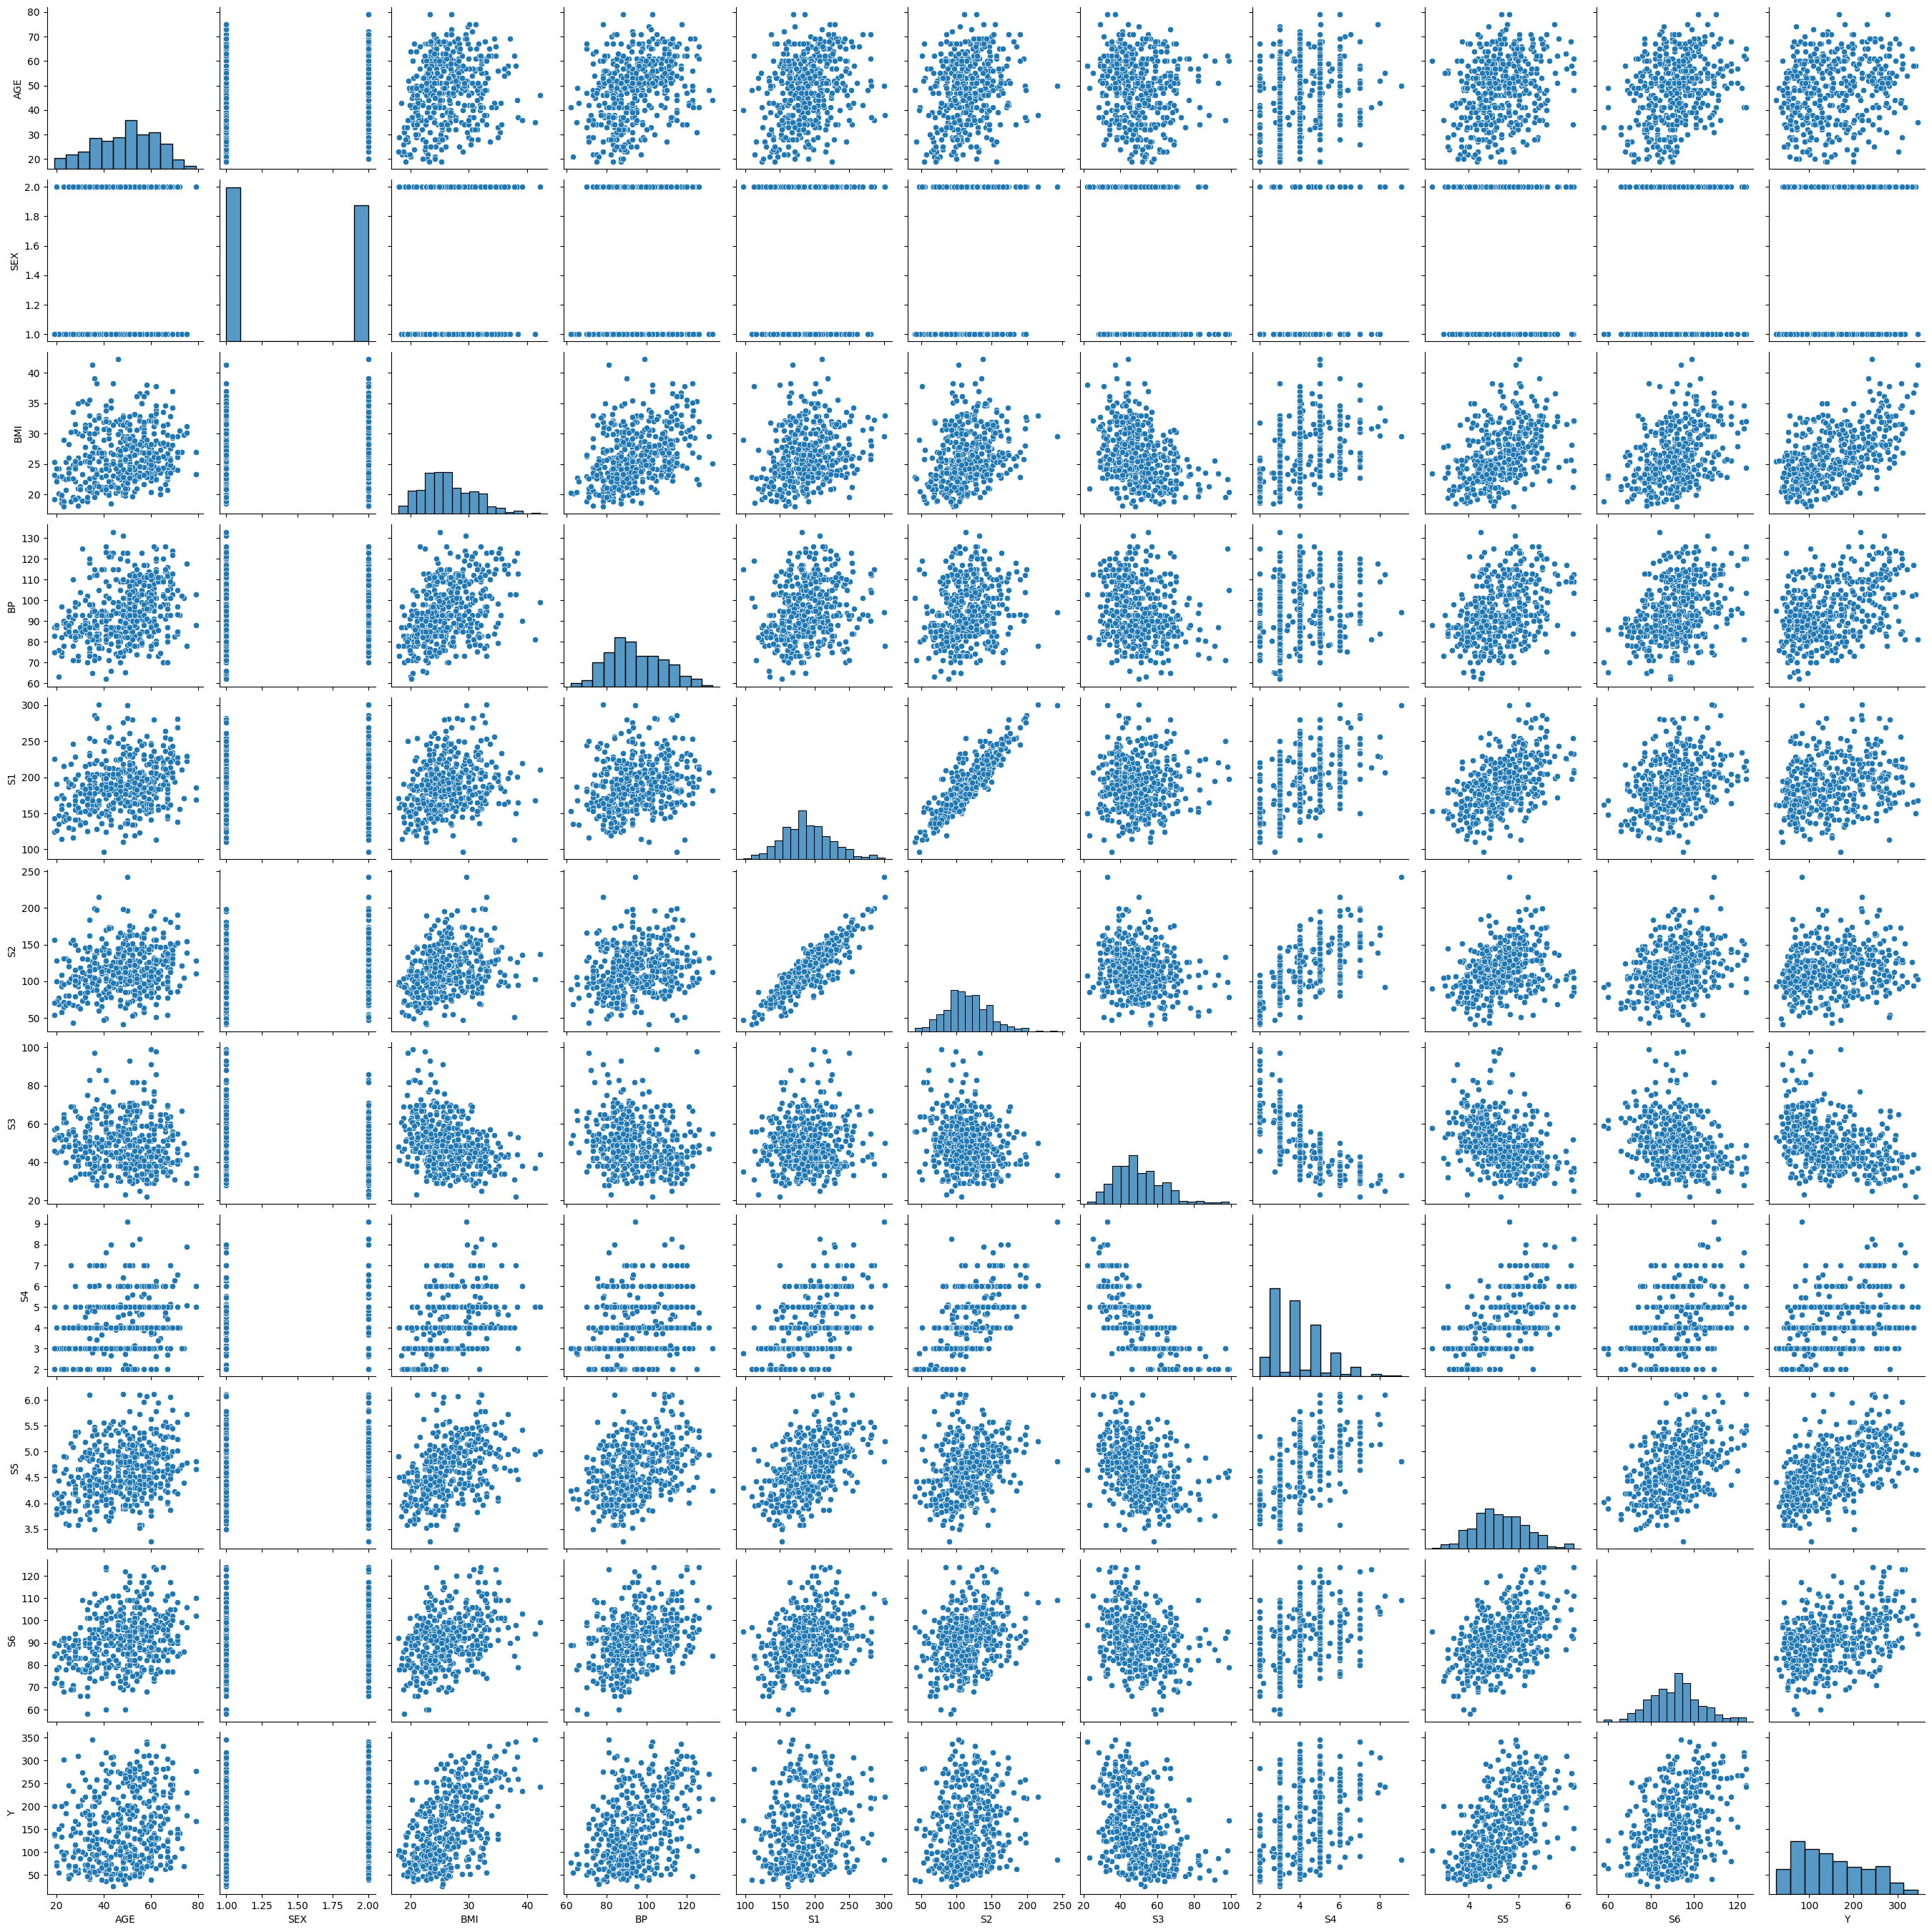

In [ ]:
diabetes_db = pd.read_csv('https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt', sep='\t', header=0)
sn.pairplot(diabetes_db)

In [ ]:
diabetes_db.head(10)

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.00,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.00,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.00,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.00,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.00,4.2905,80,135
5,23,1,22.6,89.0,139,64.8,61.0,2.00,4.1897,68,97
6,36,2,22.0,90.0,160,99.6,50.0,3.00,3.9512,82,138
7,66,2,26.2,114.0,255,185.0,56.0,4.55,4.2485,92,63
8,60,2,32.1,83.0,179,119.4,42.0,4.00,4.4773,94,110
9,29,1,30.0,85.0,180,93.4,43.0,4.00,5.3845,88,310


In [ ]:
diabetes_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     442 non-null    int64  
 1   SEX     442 non-null    int64  
 2   BMI     442 non-null    float64
 3   BP      442 non-null    float64
 4   S1      442 non-null    int64  
 5   S2      442 non-null    float64
 6   S3      442 non-null    float64
 7   S4      442 non-null    float64
 8   S5      442 non-null    float64
 9   S6      442 non-null    int64  
 10  Y       442 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 38.1 KB


In [ ]:
diabetes_db.describe()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


We first split the data into test and training sets. For consistency and to allow for meaningful comparison the same splits are maintained in the remainder of the lab.

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    diabetes_db.loc[:, diabetes_db.columns != 'Y'],
    diabetes_db['Y'],
    test_size=0.2,
    random_state=42
    )
x_train = torch.from_numpy(X_train.values).float()
x_test = torch.from_numpy(X_test.values).float()

y_train = torch.from_numpy(y_train.values).float()
y_train = y_train.reshape(-1, 1)

y_test = torch.from_numpy(y_test.values).float()
y_test = y_test.reshape(-1, 1)

print("x shape train is", x_train.shape,"y train shape is",  y_train.shape)
print("x test shape is", x_test.shape,"y test shape is", y_test.shape)


x shape train is torch.Size([353, 10]) y train shape is torch.Size([353, 1])
x test shape is torch.Size([89, 10]) y test shape is torch.Size([89, 1])


We can see that all the independent variables are on different scales. This can affect gradient descent, we therefore need to normalize all features to zero mean, and unit standard deviation. The normalized value $z_i$ of $x_i$ is obtained through $z_i = \frac{x_i - μ}{σ}$ where $μ$ is the mean and $σ$ is the standard deviation of $X$ and $x_i, μ, σ ∈ \mathbb{R}^D$.

**Q1.** Complete the method and normalize `x_train, x_test` [2 marks]

In [ ]:
def norm_set(x: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor) -> torch.tensor:
  ### your code here
    #formula: Zi(normalised) = (xi - mu) / sigma
    x_norm = (x -mu) / sigma
    return x_norm

#mean and std for all columns
mu = x_train.mean(dim= 0, keepdim = True)
sigma = x_train.std(dim= 0, keepdim = True)

#apply the normalisation to train and test data
x_train = norm_set(x_train, mu, sigma)
x_test = norm_set(x_test, mu, sigma)
###your code here


## 1.1 Linear Regression

We will building the linear regression model in pytorch using a custom layer.

Refering back to the lecture notes, we define $ y = f(x) = w^T x$, so we need to learn weight vector $w$.

**Q2.** Fill in the forward method of the LinearRegression class. [2 marks]

In [ ]:
class LinearRegression(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.weight = nn.Parameter(torch.ones(1, num_features), requires_grad=False)

  def forward(self, x):
    y = 0
    # y = x 'x' w^T
    y = torch.matmul(x, self.weight.T)
    ### your code here
    return y


As we need to account for the bias, we add a column of ones to the `x_data`

In [ ]:
# add a feature for bias
x_train = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1)
x_test = torch.cat([x_test, torch.ones(x_test.shape[0], 1)], dim=1)

In [ ]:
## test the custom layer
model = LinearRegression(x_train.shape[1])
prediction = model(x_train)
prediction.shape # the output should be Nx1

torch.Size([353, 1])

The next step is to calculate the cost. For this we will use the mean squared error $E(w) = \frac{1}{N} Σ_{i=0}^N (f(x_i) - y_i)^2$

**Q3.** Fill in the method to calculate the squared error of for any set of labels $y$ and predictions [2 marks]

In [ ]:
def mean_squared_error(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    # mean squared error = 1/N x sum(y_true - y_pred)^2
  ### your code here
  return torch.mean((y_true - y_pred)**2)

In [ ]:
cost = mean_squared_error(y_train, prediction)
print(cost)

tensor(29029.5645)


We see that using a random set of initial parameters for bias and weight, yields a relatively high error. As such, we will update the values for $w$ using gradient descent. We will implement a custom method for gradient descent.

**Q4.** In the method below, add your code to update bias and weight using learning rate $α$. [2 marks]

First you need to calculate the partial derivative of the loss function with respect to the weights.

We then update the weights vector using the following equation:

$ weight = weight - α * ∂_{weight}$

In [ ]:
def gradient_descent_step(model: nn.Module, X: torch.Tensor, y: torch.Tensor, y_pred: torch.Tensor, lr: float) -> None:
  weight = model.weight
  N = X.shape[0]
  #derived from the mean squared error, E(w) = (1/N) x (yi - w^T x)^2
  # dE(w)/ dw = -2/N x x(y-w^Tx)
  gradient = (-2/ N) * torch.matmul(X.T, (y - y_pred))

  #weight = weight - alpha x gradient(transposed so the multiplication can be applied)
  weight = weight - lr * gradient.T
  ### your code here
  # calculate the partial derivative of the loss function with respect to w
  # calculate the new values the weights
  model.weight = nn.Parameter(weight, requires_grad=False)

Iteration 0, Cost: 29029.564453125
Iteration 10, Cost: 19620.333984375
Iteration 20, Cost: 13911.51953125
Iteration 30, Cost: 10217.0009765625
Iteration 40, Cost: 7776.39501953125
Iteration 50, Cost: 6153.7001953125
Iteration 60, Cost: 5072.40673828125
Iteration 70, Cost: 4351.1640625
Iteration 80, Cost: 3869.772705078125
Iteration 90, Cost: 3548.286865234375


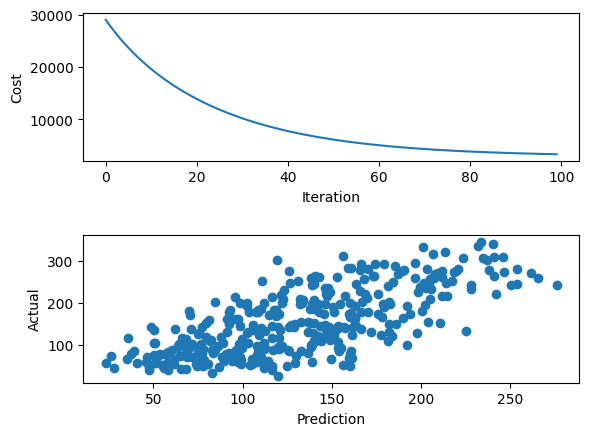

Parameter containing:
tensor([[  2.0440,  -8.9550,  23.8555,  15.2730,  -3.3063,  -5.4048,  -9.5767,
           7.1891,  17.6155,   5.7776, 133.4807]])
Minimum cost: 3351.2705078125


In [ ]:
cost_lst = list()
model = LinearRegression(x_train.shape[1])
# Reduced alpha from 0.1 to 0.01
alpha = .01
for it in range(100):
  prediction = model(x_train)
  cost = mean_squared_error(y_train, prediction)
  cost_lst.append(cost)
  gradient_descent_step(model, x_train, y_train, prediction, alpha)
  if it % 10 == 0:
    print(f"Iteration {it}, Cost: {cost.item()}") #check the gradient isn't exploding


fig, axs = plt.subplots(2)
axs[0].plot(list(range(it+1)), cost_lst)
axs[1].scatter(prediction, y_train)

axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Cost')
axs[1].set_xlabel('Prediction')
axs[1].set_ylabel('Actual')

plt.subplots_adjust(hspace=0.5)
plt.show()
print(model.weight)
print('Minimum cost: {}'.format(min(cost_lst)))

<font color="maroon">**Q5.** What conclusion if any can be drawn from the weight values? How does sex and BMI affect diabetes disease progression?

What are the estimated disease progression values for the below examples? [2 marks] </font>

| AGE | SEX | BMI | BP  | S1  | S2    | S3 | S4  | S5     | S6  |
|-----|-----|-----|-----|-----|-------|----|-----|--------|-----|
| 25  | F   | 18  | 79  | 130 | 64.8  | 61 | 2   | 4.1897 | 68  |
| 50  | M   | 28  | 103 | 229 | 162.2 | 60 | 4.5 | 6.107  | 124 |

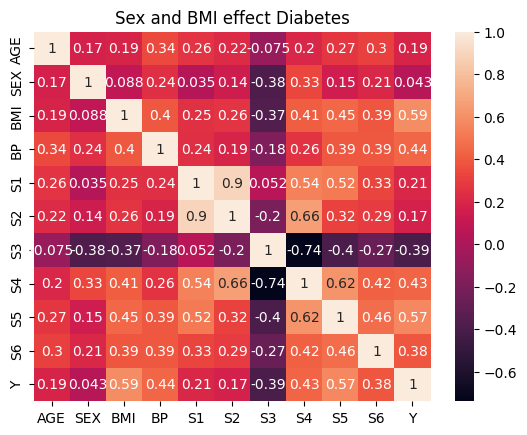

25F, BMI=18: 41.30
50M, BMI=28: 187.78
BMI correlation with Y: 0.5865
SEX correlation with Y: 0.0431


In [ ]:
correlation = diabetes_db.corr()
sn.heatmap(correlation, annot=True)
plt.title('Sex and BMI effect Diabetes')
plt.show()

# estimated disease progression for values provided
F = torch.tensor([[25, 1, 18, 79, 130, 64.8, 61, 2, 4.1897, 68]])
M = torch.tensor([[50, 2, 28, 103, 229, 162.2, 60, 4.5, 6.107, 124]])

# Normalizing data
F_norm = norm_set(F, mu, sigma)
M_norm = norm_set(M, mu, sigma)

# Adding bias
F_norm = torch.cat([F_norm, torch.ones(1, 1)], dim=1)
M_norm = torch.cat([M_norm, torch.ones(1, 1)], dim=1)

# Predictions
prediction_1 = model(F_norm)
prediction_2 = model(M_norm)

print(f"25F, BMI=18: {prediction_1.item():.2f}")
print(f"50M, BMI=28: {prediction_2.item():.2f}")

print(f"BMI correlation with Y: {correlation.loc['BMI', 'Y']:.4f}")
print(f"SEX correlation with Y: {correlation.loc['SEX', 'Y']:.4f}")
### your code here


Now estimate the error on the test set. Is the error on the test set comparable to that of the train set? What can be said about the fit of the model? When does a model over/under fits?


In [ ]:
### your code here

train_predict = model(x_train)
test_predict = model(x_test)

#Get the mse for both train and test
train_error = torch.mean((y_train - train_predict)**2)
test_error = torch.mean((y_test - test_predict)**2)


print(f"Train error: {train_error}")
print(f"Test error: {test_error}")

error_comparable = ((test_error - train_error) / train_error) * 100
print(f"{error_comparable.item():.1f}%")


if error_comparable.item() >20:
  print('Overfitting')
elif error_comparable.item() < -10:
  print('Underfitting')
else:
  print('Good fit')

Train error: 3333.46875
Test error: 3425.4423828125
2.8%
Good fit


<font color="maroon">**Q6.** Try the code with several learning rates that differ by orders of magnitude, and record the training and test set errors. Describe the theory of how changing the learning rate affects learning. What do you observe in the training error? How about the error on the test set? [3 marks]</font>

Iteration 0, Cost: 29029.564453125
Iteration 10, Cost: 28907.708984375
Iteration 20, Cost: 28786.615234375
Iteration 30, Cost: 28666.26953125
Iteration 40, Cost: 28546.662109375
Iteration 50, Cost: 28427.796875
Iteration 60, Cost: 28309.65234375
Iteration 70, Cost: 28192.232421875
Iteration 80, Cost: 28075.52734375
Iteration 90, Cost: 27959.5234375
Test error: 25102.232421875
Iteration 0, Cost: 29029.564453125
Iteration 10, Cost: 28786.578125
Iteration 20, Cost: 28546.591796875
Iteration 30, Cost: 28309.54296875
Iteration 40, Cost: 28075.3828125
Iteration 50, Cost: 27844.05078125
Iteration 60, Cost: 27615.498046875
Iteration 70, Cost: 27389.677734375
Iteration 80, Cost: 27166.529296875
Iteration 90, Cost: 26946.01171875
Test error: 24190.095703125
Iteration 0, Cost: 29029.564453125
Iteration 10, Cost: 28666.158203125
Iteration 20, Cost: 28309.43359375
Iteration 30, Cost: 27959.20703125
Iteration 40, Cost: 27615.294921875
Iteration 50, Cost: 27277.521484375
Iteration 60, Cost: 26945.722

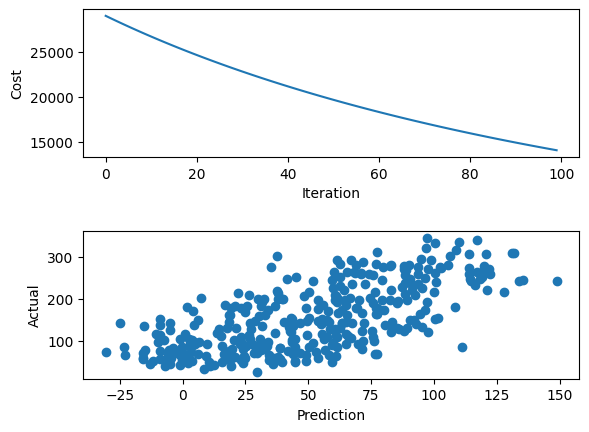

Parameter containing:
tensor([[ 3.0562, -1.1360, 12.3833,  8.7762,  1.6111,  0.6307, -5.5644,  6.5853,
         10.2372,  6.3775, 51.4363]])
Minimum cost: 14080.833984375
 Learning Rate  Training Error   Test Error
        0.0001    27855.724609 25102.232422
        0.0002    26749.755859 24190.095703
        0.0003    25705.841797 23326.492188
        0.0010    19769.701172 18346.242188
        0.0020    14080.833984 13412.851562


In [ ]:
### your code here
lr = [0.0001, 0.0002, 0.0003, 0.001, 0.002]
results = []

for alpha in lr:
    cost_lst = list()
    model = LinearRegression(x_train.shape[1])


    for it in range(100):
        prediction = model(x_train)
        cost = mean_squared_error(y_train, prediction)
        cost_lst.append(cost)
        gradient_descent_step(model, x_train, y_train, prediction, alpha)

        if it % 10 == 0:
            print(f"Iteration {it}, Cost: {cost.item()}")

    with torch.no_grad():
        test_prediction = model(x_test)
        test_error = mean_squared_error(y_test, test_prediction)
        print(f"Test error: {test_error}")

    train_error = min(cost_lst)
    results.append({'Learning Rate': alpha,'Training Error': train_error.item(),'Test Error': test_error.item()})


   #print(f"α={alpha:.4f} Train Error: {train_error:.2f} Test Error: {test_error:.2f}")


fig, axs = plt.subplots(2)
axs[0].plot(list(range(it+1)), cost_lst)
axs[1].scatter(prediction, y_train)
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Cost')
axs[1].set_xlabel('Prediction')
axs[1].set_ylabel('Actual')
plt.subplots_adjust(hspace=0.5)
plt.show()
print(model.weight)
print('Minimum cost: {}'.format(min(cost_lst)))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

#I can see as the learning rate is increasing, both training and test errors are decreasing
#Smaller learning rates are resulting in slower learning, test error is consistently lower then training error
#best lr is 0.002,α=0.0002 Train Error: 26749.76 Test Error: 24190.10


# 1.2 Regularized Linear Regression
In this exercise, we will be trying to create a model that fits data that is clearly not linear. We will be attempting to fit the data points seen in the graph below:

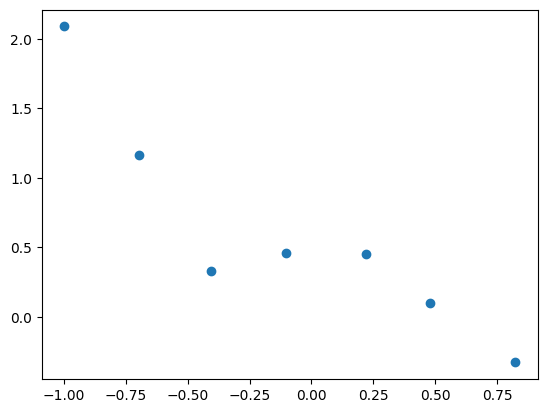

In [ ]:
x = torch.tensor([-0.99768, -0.69574, -0.40373, -0.10236, 0.22024, 0.47742, 0.82229])
y = torch.tensor([2.0885, 1.1646, 0.3287, 0.46013, 0.44808, 0.10013, -0.32952]).reshape(-1, 1)
plt.scatter(x, y)
plt.show()

In order to fit this data we will create a new hypothesis function, which uses a fifth-order polynomial:

$
 h_{\theta}(x) = \theta_{0} x_{0} + \theta_{1} x_{1} + \theta_{2} x_{1} ^2 + \theta_{3} x_{1} ^3 + \theta_{4} x_{1} ^4 + \theta_{5} x_{1} ^5
$

As we are fitting a small number of points with a high order model, there is a danger of overfitting.  \\

To attempt to avoid this we will use regularization. Our cost function becomes:

$
 J(\theta) = \frac{1}{2m}  \left[ \sum_{i=1}^m ( h_{\theta}(x^{(i)}) - y^{(i)})^2 + \lambda    \sum_{j=1}^n \theta_{j}^2 \right]
$

Adjust variable `x` to include the different powers of $x_{1}$ as described by the hypothesis function. e.g $x_{1}, x_{1} ^2, ..., x_{1}^5$. Hint: Remember to include $x_0$ which is our bias term.

In [ ]:
### your code here. please assign it to the python object 'x3'. e.g x3 = .....

polynomial_values = []
max_element = 6

for element in range(max_element + 1):
    if element ==0:
      value = torch.ones_like(x)
    else:
      value = x** element
    polynomial_values.append(value)
x3 = torch.stack(polynomial_values, dim=1)
print(x3)

tensor([[ 1.0000e+00, -9.9768e-01,  9.9537e-01, -9.9306e-01,  9.9075e-01,
         -9.8845e-01,  9.8616e-01],
        [ 1.0000e+00, -6.9574e-01,  4.8405e-01, -3.3678e-01,  2.3431e-01,
         -1.6302e-01,  1.1342e-01],
        [ 1.0000e+00, -4.0373e-01,  1.6300e-01, -6.5807e-02,  2.6568e-02,
         -1.0726e-02,  4.3306e-03],
        [ 1.0000e+00, -1.0236e-01,  1.0478e-02, -1.0725e-03,  1.0978e-04,
         -1.1237e-05,  1.1502e-06],
        [ 1.0000e+00,  2.2024e-01,  4.8506e-02,  1.0683e-02,  2.3528e-03,
          5.1818e-04,  1.1412e-04],
        [ 1.0000e+00,  4.7742e-01,  2.2793e-01,  1.0882e-01,  5.1952e-02,
          2.4803e-02,  1.1841e-02],
        [ 1.0000e+00,  8.2229e-01,  6.7616e-01,  5.5600e-01,  4.5719e-01,
          3.7595e-01,  3.0914e-01]])


**Q7.** Update the cost and gradient descent methods to use the regularised cost, as shown above. [4 marks]

Note that the punishment for having more terms is not applied to the bias. This means that we use a different update technique for the partial derivative of $\theta_{0}$, and add the regularization to all of the others:



$
 \theta_{j} =  \theta_{j} - \alpha \frac{1}{m} \sum_{i=1}^m ( h_{\theta}(x^{(i)}) - y^{(i)})x^{(i)}_{j} , j=0
$



$
 \theta_{j} =  \theta_{j} (1 - \alpha \frac{\lambda}{m}) -
 \alpha \frac{1}{m} \sum_{i=1}^m ( h_{\theta}(x^{(i)}) - y^{(i)})x^{(i)}_{j} , j>0
$

In [ ]:
def mean_squared_error(y_true: torch.Tensor, y_pred: torch.Tensor, lam: float, theta: torch.tensor) -> torch.Tensor:
    # J(theta) = 1/2(theta(x) - y) + lam sumtheta^2
    #regularised, J(theta) = 1/2m( theta(x) - y)^2 + lam theta^2
    # mean squared error = 1/N x sum(y_true - y_pred)
    N = y_true.shape[0]
    mean_squared_error = (1/(2*N)) * torch.sum((y_pred - y_true)**2)
    regularised = (lam/(2*N)) * torch.sum(theta[:, 1:]**2)

  ### your code here
    return mean_squared_error + regularised

def gradient_descent_step(model: nn.Module, X: torch.Tensor, y: torch.Tensor, y_pred: torch.Tensor, lr: float, lam: float) -> None:
  weight = model.weight
  N = X.shape[0]

  gradient = (1/N) * torch.matmul(X.T, (y_pred - y))

  weight[0, 0] = weight[0,0] - lr * gradient[0]
  for j in range(1, weight.shape[1]):
    weight[0, j] = weight[0, j] * (1 - lr * lam / N) - lr * gradient[j]


  #weight = weight - alpha x gradient(transposed so the multiplication works)
  #weight = weight * (1 - lr * lam / N * regularised) - lr * gradient.T
  ### your code here
  ###
  model.weight = nn.Parameter(weight, requires_grad=False)


<font color="maroon"> **Q8.** First of all, find the best value of alpha to use in order to optimize best.
Next, experiment with different values of $\lambda$ and see how this affects the shape of the hypothesis. [3 marks]</font>

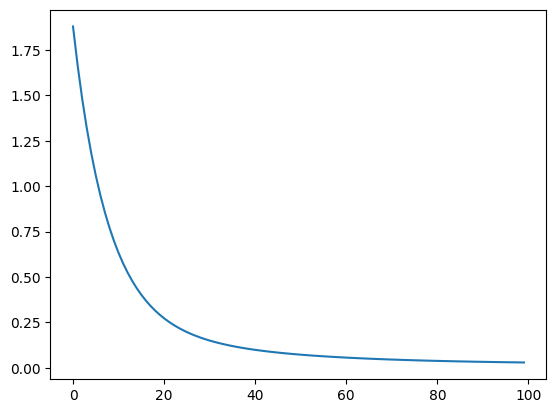

Parameter containing:
tensor([[ 0.2437, -0.7511,  0.1172, -0.2114,  0.4002,  0.1706,  0.6057]])
Minimum cost: 0.029659021645784378
Training with α=0.1, λ=0.01
Final cost: 0.029659


In [ ]:

'''
cost_lst = list()
model = LinearRegression(x3.shape[1])
alpha_values = [0.001, 0.003, 0.01, 0.03, 0.05, 0.1]
best_alpha = 0
best_cost = float('inf')
lam = 0

plt.figure(figsize=(10, 6))

for test_alpha in alpha_values:
    cost_lst = list()
    model = LinearRegression(x3.shape[1])

    for it in range(100):
        prediction = model(x3)
        cost = mean_squared_error(y, prediction, lam, model.weight)
        cost_lst.append(cost)
        gradient_descent_step(model, x3, y, prediction, test_alpha, lam)

    final_cost = cost_lst[-1].item()

    if final_cost < best_cost:
        best_cost = final_cost
        best_alpha = test_alpha

    # Ploting all on same graph to compare the alphas
    plt.plot(list(range(it+1)), cost_lst, linewidth=2, label=f'alpha={test_alpha}')

plt.title('Cost Convergence Comparison for Different Learning Rates', fontsize=14, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale to see all curves clearly because values are so small
plt.show()

print(f'best alpha to use: {best_alpha}')
print(f'best cost: {best_cost:.6f}')


#Lambda testing with the best alpha found (0.1)

# Show all Lambda values on one graph
lambda_values = [0, 0.01, 0.001, 0.1, 1.0, 10.0]
alpha = 0.1  # best one found in above testing
best_lambda = 0
best_lambda_cost = float('inf')

plt.figure(figsize=(10, 6))

for test_lam in lambda_values:
    cost_lst = list()
    model = LinearRegression(x3.shape[1])
    lam = test_lam

    for it in range(100):
        prediction = model(x3)
        cost = mean_squared_error(y, prediction, lam, model.weight)
        cost_lst.append(cost)
        gradient_descent_step(model, x3, y, prediction, alpha, lam)

    final_cost = cost_lst[-1].item()

    # Track best lambda
    if final_cost < best_lambda_cost:
        best_lambda_cost = final_cost
        best_lambda = lam

    # Plot all on same graph
    plt.plot(list(range(it+1)), cost_lst, linewidth=2, label=f'Lambda={lam}')

plt.title(f'Cost Convergence Comparison for Different Lambda Values (Alpha={alpha})', fontsize=14, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale to see all curves clearly because values are so small
plt.show()

print(f'best Lambda to use: {best_lambda}')
print(f'best cost: {best_lambda_cost:.6f}')

'''
# From the above the best alpha and Lambda values have been found, the model now need to be trained with specific alpha and lambda before plotting
cost_lst = list()
model = LinearRegression(x3.shape[1])
alpha = 0.1  # best alpha value
lam = 0.01     # best lambda value for implementation

for it in range(100):
    prediction = model(x3)
    cost = mean_squared_error(y, prediction, lam, model.weight)
    cost_lst.append(cost)
    gradient_descent_step(model, x3, y, prediction, alpha, lam)
display.clear_output(wait=True)
plt.plot(list(range(it+1)), cost_lst)
plt.show()
print(model.weight)
print('Minimum cost: {}'.format(min(cost_lst)))

print(f'Training with α={alpha}, λ={lam}')
print(f'Final cost: {min(cost_lst):.6f}')




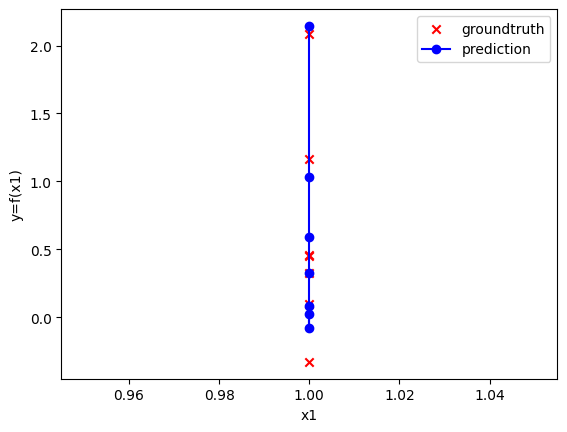

In [ ]:

plt.scatter(x3[:, 0], y, c='red', marker='x', label='groundtruth')
outputs = model(x3)
plt.plot(x3[:, 0], outputs, c='blue', marker='o', label='prediction')
plt.xlabel('x1')
plt.ylabel('y=f(x1)')
plt.legend()
plt.show()